In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

In [2]:
import sys
from packaging import version
import sklearn

# Check Python version
if sys.version_info < (3, 7):
    raise ValueError(f"Python version must be 3.7 or higher. Found: {sys.version_info.major}.{sys.version_info.minor}")

# Check Scikit-learn version
if version.parse(sklearn.__version__) < version.parse("1.0.1"):
    raise ValueError(f"Scikit-learn version must be 1.0.1 or higher. Found: {sklearn.__version__}")

print("Environment checks passed: Python and Scikit-learn versions meet requirements.")

Environment checks passed: Python and Scikit-learn versions meet requirements.


In [3]:

from pathlib import Path  # Importing the Path class from the pathlib module to handle file system paths
import pandas as pd  # Importing pandas as pd for data manipulation and analysis
import tarfile  # Importing the tarfile module to work with tar archive files
import urllib.request  # Importing urllib.request to handle URL operations


In [4]:
def load_bitcoin_data():
    bitcoin_path = Path("btcusd_1-min_data.csv")

    if not bitcoin_path.is_file():
       print("NOT FOUND")
        
    return pd.read_csv(Path("btcusd_1-min_data.csv"))

bitcoin = load_bitcoin_data()
print("Bitcoin data loaded successfully.")

Bitcoin data loaded successfully.


In [5]:
bitcoin.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [6]:
bitcoin['Timestamp'] = pd.to_datetime(bitcoin['Timestamp'], unit='s')
bitcoin = bitcoin.sort_values('Timestamp').reset_index(drop=True)
bitcoin.dropna(inplace=True)

def engineer_features(df):
    df = df.copy()

    # =====================================================
    # LOG PRICE FEATURES
    # =====================================================

    df['log_close'] = np.log(df['Close'])
    df['log_open'] = np.log(df['Open'])

    # =====================================================
    # PRICE ACTION
    # =====================================================

    df['price_range_pct'] = (
        (df['High'] - df['Low']) / df['Close']
    )

    df['body_pct'] = (
        (df['Close'] - df['Open']) / df['Open']
    )

    # =====================================================
    # RETURNS
    # =====================================================

    df['return_1'] = df['Close'].pct_change(1)
    df['return_5'] = df['Close'].pct_change(5)
    df['return_10'] = df['Close'].pct_change(10)

    # =====================================================
    # MOVING AVERAGES
    # =====================================================

    df['sma_10'] = df['Close'].rolling(10).mean()
    df['sma_30'] = df['Close'].rolling(30).mean()

    # Distance from moving averages
    df['dist_sma_10'] = (
        (df['Close'] - df['sma_10']) / df['sma_10']
    )

    df['dist_sma_30'] = (
        (df['Close'] - df['sma_30']) / df['sma_30']
    )

    # =====================================================
    # VOLATILITY
    # =====================================================

    df['volatility_10'] = (
        df['return_1'].rolling(10).std()
    )

    # =====================================================
    # VOLUME
    # =====================================================

    df['volume_change'] = df['Volume'].pct_change()

    # =====================================================
    # TIME FEATURES
    # =====================================================

    df['hour'] = df['Timestamp'].dt.hour
    df['dayofweek'] = df['Timestamp'].dt.dayofweek
    df['month'] = df['Timestamp'].dt.month

    # =====================================================
    # TARGET
    # =====================================================

    # Predict next-period return
    df['target'] = (
        df['Close'].shift(-1) / df['Close'] - 1
    )

    # Clean invalid values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    return df


bitcoin = engineer_features(bitcoin)
print(bitcoin.shape)
bitcoin.head()

(6247758, 23)


,Timestamp,Open,High,Low,Close,Volume,log_close,log_open,price_range_pct,body_pct,...,sma_10,sma_30,dist_sma_10,dist_sma_30,volatility_10,volume_change,hour,dayofweek,month,target
628,2012-01-01 20:29:00,4.84,4.84,4.84,4.84,0.0,1.576915,1.576915,0.0,0.0,...,4.632,4.597333,0.044905,0.052784,0.017952,-1.0,20,6,1,1.576915
1065,2012-01-02 03:46:00,5.00,5.00,5.00,5.00,0.0,1.609438,1.609438,0.0,0.0,...,4.872,4.850667,0.026273,0.030786,0.010454,-1.0,3,0,1,1.609438
2344,2012-01-03 01:05:00,5.00,5.00,5.00,5.00,0.0,1.609438,1.609438,0.0,0.0,...,5.000,5.000000,0.000000,0.000000,0.000000,-1.0,1,1,1,1.609438
3285,2012-01-03 16:46:00,5.32,5.32,5.32,5.32,0.0,1.671473,1.671473,0.0,0.0,...,5.064,5.021333,0.050553,0.059480,0.020239,-1.0,16,1,1,1.671473
3442,2012-01-03 19:23:00,5.14,5.14,5.14,5.14,0.0,1.637053,1.637053,0.0,0.0,...,5.284,5.308000,-0.027252,-0.031650,0.010699,-1.0,19,1,1,1.637053


In [7]:
split_idx = int(len(bitcoin) * 0.8)

train_set = bitcoin.iloc[:split_idx].copy()
test_set  = bitcoin.iloc[split_idx:].copy()

FEATURE_COLS = [

    # Log prices
    'log_close',
    'log_open',

    # Candle structure
    'price_range_pct',
    'body_pct',

    # Returns
    'return_1',
    'return_5',
    'return_10',

    # Trend
    'dist_sma_10',
    'dist_sma_30',

    # Volatility
    'volatility_10',

    # Volume
    'volume_change',

    # Time
    'hour',
    'dayofweek',
    'month'
]

TARGET = 'target'

X_train = train_set[FEATURE_COLS]
y_train = train_set[TARGET]

X_test = test_set[FEATURE_COLS]
y_test = test_set[TARGET]

In [8]:
# Random Forest only

forest_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

forest_reg.fit(X_train, y_train)

# Training predictions
forest_train_preds = forest_reg.predict(X_train)



# RMSE
forest_rmse = np.sqrt(
    mean_squared_error(y_train, forest_train_preds)
)

print(f"Random Forest Train RMSE: {forest_rmse:.4f}")

Random Forest Train RMSE: 0.0016


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

forest_cv = -cross_val_score(
    forest_reg, X_train, y_train,
    scoring='neg_root_mean_squared_error',
    cv=tscv
)

print(f"Forest CV RMSE:  mean={forest_cv.mean():.4f}, std={forest_cv.std():.4f}")

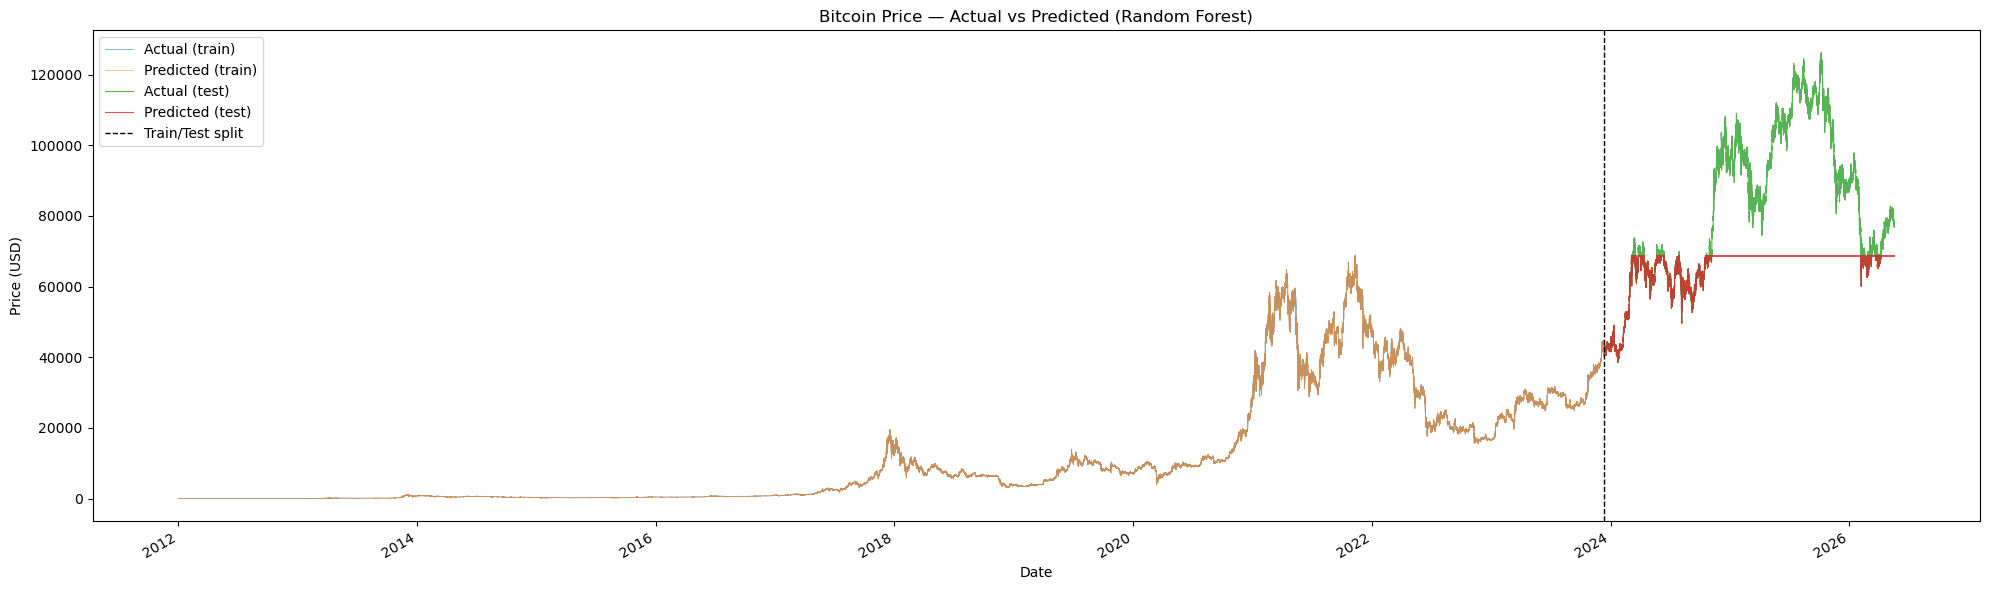

In [9]:
train_preds = forest_reg.predict(X_train)
test_preds = forest_reg.predict(X_test)

y_train_actual = np.exp(y_train)
y_test_actual = np.exp(y_test)

train_preds_actual = np.exp(train_preds)
test_preds_actual = np.exp(test_preds)

plt.figure(figsize=(20, 6))

# Train
plt.plot(train_set['Timestamp'], y_train_actual,
         label='Actual (train)', alpha=0.6, linewidth=0.6)

plt.plot(train_set['Timestamp'], train_preds_actual,
         label='Predicted (train)', alpha=0.6, linewidth=0.6)

# Test
plt.plot(test_set['Timestamp'], y_test_actual,
         label='Actual (test)', alpha=0.8, linewidth=0.8)

plt.plot(test_set['Timestamp'], test_preds_actual,
         label='Predicted (test)', alpha=0.8, linewidth=0.8)

# Split line
plt.axvline(test_set['Timestamp'].iloc[0],
            color='black', linestyle='--', linewidth=1,
            label='Train/Test split')

plt.title('Bitcoin Price — Actual vs Predicted (Random Forest)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc="upper left")
plt.gcf().autofmt_xdate()
plt.tight_layout()

plt.savefig("bitcoin_rf_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

Dataset shape: (5807634, 23)
Train size: 4646107
Test size:  1161527

Train RMSE: 24.01
Test RMSE:  56.35


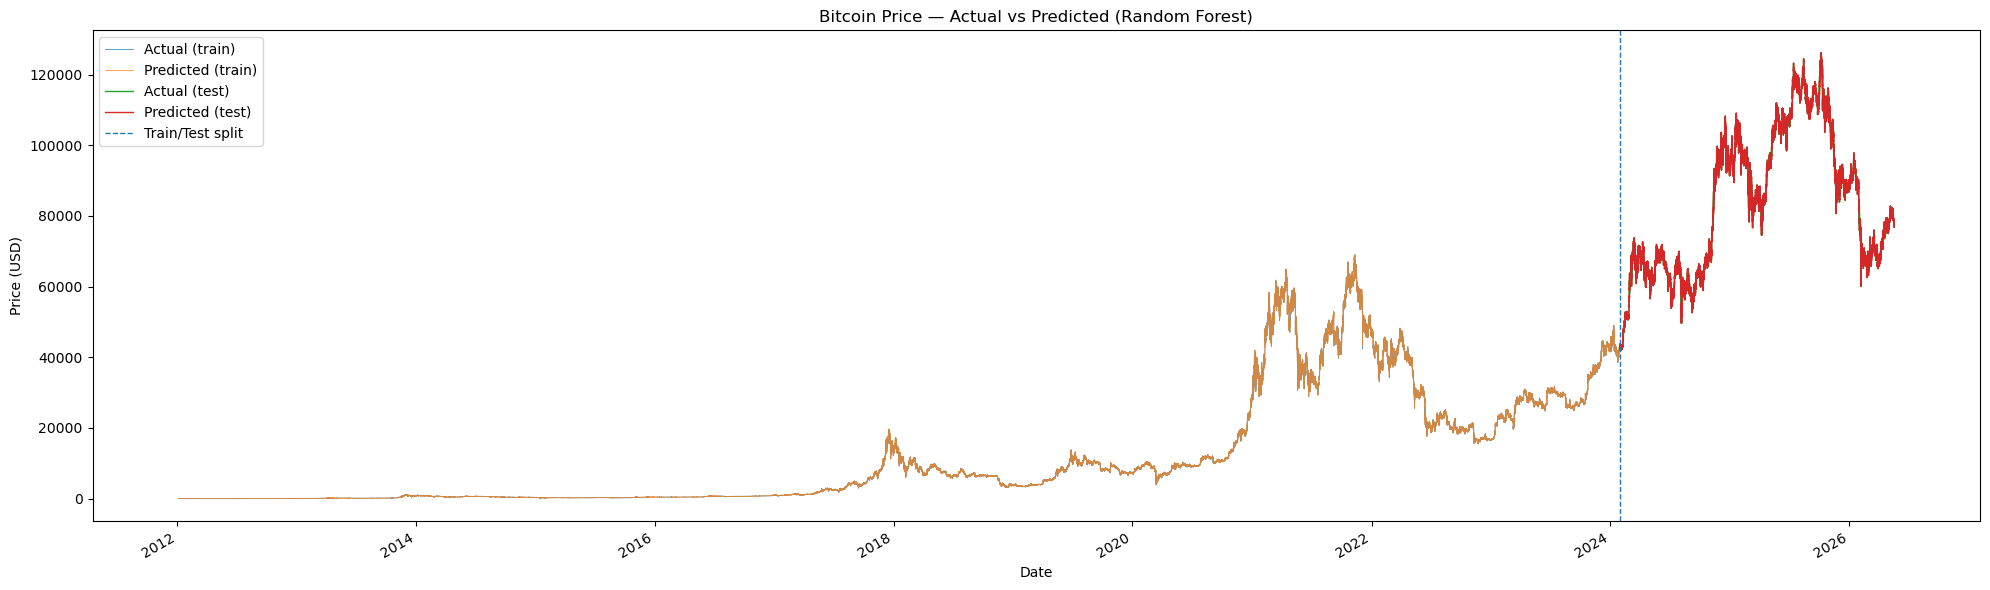

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# =========================================================
# PREPROCESSING
# =========================================================

bitcoin['Timestamp'] = pd.to_datetime(
    bitcoin['Timestamp'],
    unit='s'
)

bitcoin = bitcoin.sort_values(
    'Timestamp'
).reset_index(drop=True)

bitcoin.dropna(inplace=True)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

def engineer_features(df):

    df = df.copy()

    # -----------------------------------------------------
    # LOG PRICE FEATURES
    # -----------------------------------------------------

    df['log_close'] = np.log(df['Close'])
    df['log_open'] = np.log(df['Open'])

    # -----------------------------------------------------
    # CANDLE FEATURES
    # -----------------------------------------------------

    df['price_range_pct'] = (
        (df['High'] - df['Low']) / df['Close']
    )

    df['body_pct'] = (
        (df['Close'] - df['Open']) / df['Open']
    )

    # -----------------------------------------------------
    # RETURNS / MOMENTUM
    # -----------------------------------------------------

    df['return_1'] = df['Close'].pct_change(1)
    df['return_5'] = df['Close'].pct_change(5)
    df['return_10'] = df['Close'].pct_change(10)

    # -----------------------------------------------------
    # MOVING AVERAGES
    # -----------------------------------------------------

    df['sma_10'] = df['Close'].rolling(10).mean()
    df['sma_30'] = df['Close'].rolling(30).mean()

    # Relative position vs trend
    df['dist_sma_10'] = (
        (df['Close'] - df['sma_10'])
        / df['sma_10']
    )

    df['dist_sma_30'] = (
        (df['Close'] - df['sma_30'])
        / df['sma_30']
    )

    # -----------------------------------------------------
    # VOLATILITY
    # -----------------------------------------------------

    df['volatility_10'] = (
        df['return_1'].rolling(10).std()
    )

    # -----------------------------------------------------
    # VOLUME
    # -----------------------------------------------------

    df['volume_change'] = (
        df['Volume'].pct_change()
    )

    # -----------------------------------------------------
    # TIME FEATURES
    # -----------------------------------------------------

    df['hour'] = df['Timestamp'].dt.hour
    df['dayofweek'] = df['Timestamp'].dt.dayofweek
    df['month'] = df['Timestamp'].dt.month

    # -----------------------------------------------------
    # TARGET
    # Predict NEXT-period return
    # -----------------------------------------------------

    df['target'] = (
        df['Close'].shift(-1) / df['Close']
    ) - 1

    # -----------------------------------------------------
    # CLEANUP
    # -----------------------------------------------------

    df.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )

    df.dropna(inplace=True)

    return df


bitcoin = engineer_features(bitcoin)

print("Dataset shape:", bitcoin.shape)

# =========================================================
# FEATURE LIST
# =========================================================

FEATURE_COLS = [

    # Log prices
    'log_close',
    'log_open',

    # Candle structure
    'price_range_pct',
    'body_pct',

    # Returns
    'return_1',
    'return_5',
    'return_10',

    # Trend
    'dist_sma_10',
    'dist_sma_30',

    # Volatility
    'volatility_10',

    # Volume
    'volume_change',

    # Time
    'hour',
    'dayofweek',
    'month'
]

TARGET = 'target'

# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

split_idx = int(len(bitcoin) * 0.8)

train_set = bitcoin.iloc[:split_idx].copy()
test_set = bitcoin.iloc[split_idx:].copy()

X_train = train_set[FEATURE_COLS]
y_train = train_set[TARGET]

X_test = test_set[FEATURE_COLS]
y_test = test_set[TARGET]

print(f"Train size: {len(train_set)}")
print(f"Test size:  {len(test_set)}")

# =========================================================
# RANDOM FOREST MODEL
# =========================================================

forest_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

forest_reg.fit(X_train, y_train)

# =========================================================
# PREDICTIONS
# =========================================================

train_return_preds = forest_reg.predict(X_train)
test_return_preds = forest_reg.predict(X_test)

# =========================================================
# REBUILD PRICE PREDICTIONS
# =========================================================

train_preds_actual = (
    train_set['Close'].values *
    (1 + train_return_preds)
)

test_preds_actual = (
    test_set['Close'].values *
    (1 + test_return_preds)
)

# Actual next prices
y_train_actual = (
    train_set['Close'].shift(-1)
)

y_test_actual = (
    test_set['Close'].shift(-1)
)

# Remove final NaN alignment row
train_preds_actual = train_preds_actual[:-1]
test_preds_actual = test_preds_actual[:-1]

y_train_actual = y_train_actual.iloc[:-1]
y_test_actual = y_test_actual.iloc[:-1]

train_plot_time = train_set['Timestamp'].iloc[:-1]
test_plot_time = test_set['Timestamp'].iloc[:-1]

# =========================================================
# RMSE
# =========================================================

train_rmse = np.sqrt(
    mean_squared_error(
        y_train_actual,
        train_preds_actual
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        test_preds_actual
    )
)

print(f"\nTrain RMSE: {train_rmse:,.2f}")
print(f"Test RMSE:  {test_rmse:,.2f}")

# =========================================================
# OPTIONAL CROSS VALIDATION
# =========================================================

RUN_CV = False

if RUN_CV:

    tscv = TimeSeriesSplit(n_splits=3)

    cv_scores = -cross_val_score(
        forest_reg,
        X_train,
        y_train,
        scoring='neg_root_mean_squared_error',
        cv=tscv
    )

    print("\nCross Validation RMSE")
    print(f"Mean: {cv_scores.mean():.6f}")
    print(f"Std:  {cv_scores.std():.6f}")

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(20, 6))

# Train actual
plt.plot(
    train_plot_time,
    y_train_actual,
    label='Actual (train)',
    linewidth=0.7,
    alpha=0.7
)

# Train predicted
plt.plot(
    train_plot_time,
    train_preds_actual,
    label='Predicted (train)',
    linewidth=0.7,
    alpha=0.7
)

# Test actual
plt.plot(
    test_plot_time,
    y_test_actual,
    label='Actual (test)',
    linewidth=1
)

# Test predicted
plt.plot(
    test_plot_time,
    test_preds_actual,
    label='Predicted (test)',
    linewidth=1
)

# Train/test split line
plt.axvline(
    test_plot_time.iloc[0],
    linestyle='--',
    linewidth=1,
    label='Train/Test split'
)

plt.title(
    'Bitcoin Price — Actual vs Predicted (Random Forest)'
)

plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.legend(loc='upper left')

plt.gcf().autofmt_xdate()

plt.tight_layout()

# Save figure
plt.savefig(
    'bitcoin_random_forest_prediction.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [11]:
tscv = TimeSeriesSplit(n_splits=5)

forest_cv = -cross_val_score(
    forest_reg, X_train, y_train,
    scoring='neg_root_mean_squared_error',
    cv=tscv
)


In [12]:
print(f"Forest CV RMSE:  mean={forest_cv.mean():.4f}, std={forest_cv.std():.4f}")

Forest CV RMSE:  mean=0.0012, std=0.0003


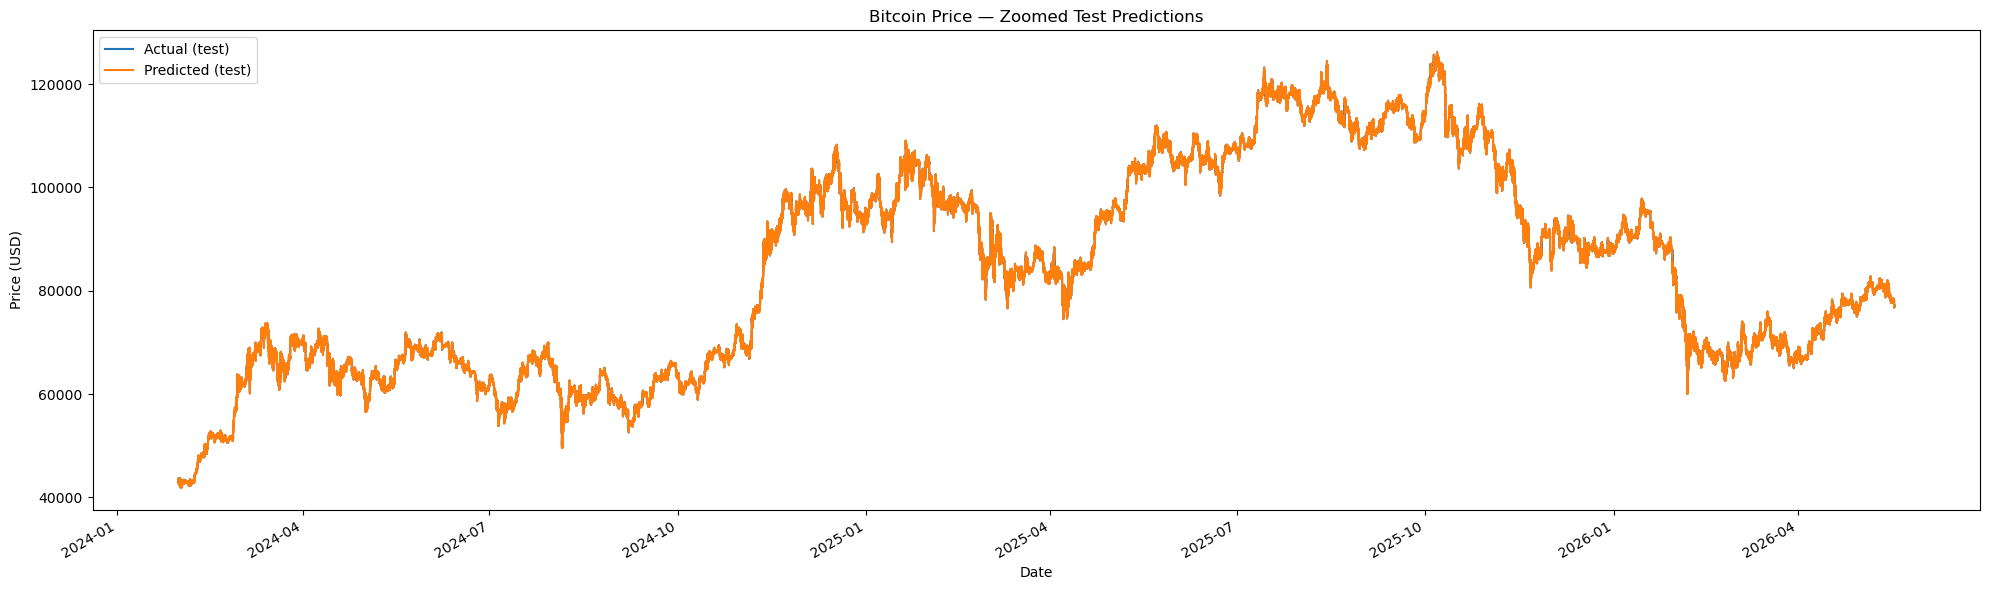

In [13]:
# =========================================================
# ZOOMED TEST SET PLOT
# =========================================================

plt.figure(figsize=(20, 6))

# Actual test prices
plt.plot(
    test_plot_time,
    y_test_actual,
    label='Actual (test)',
    linewidth=1.5
)

# Predicted test prices
plt.plot(
    test_plot_time,
    test_preds_actual,
    label='Predicted (test)',
    linewidth=1.5
)

plt.title('Bitcoin Price — Zoomed Test Predictions')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.legend(loc='upper left')

plt.gcf().autofmt_xdate()

plt.tight_layout()

plt.savefig(
    'bitcoin_zoomed_test_predictions.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

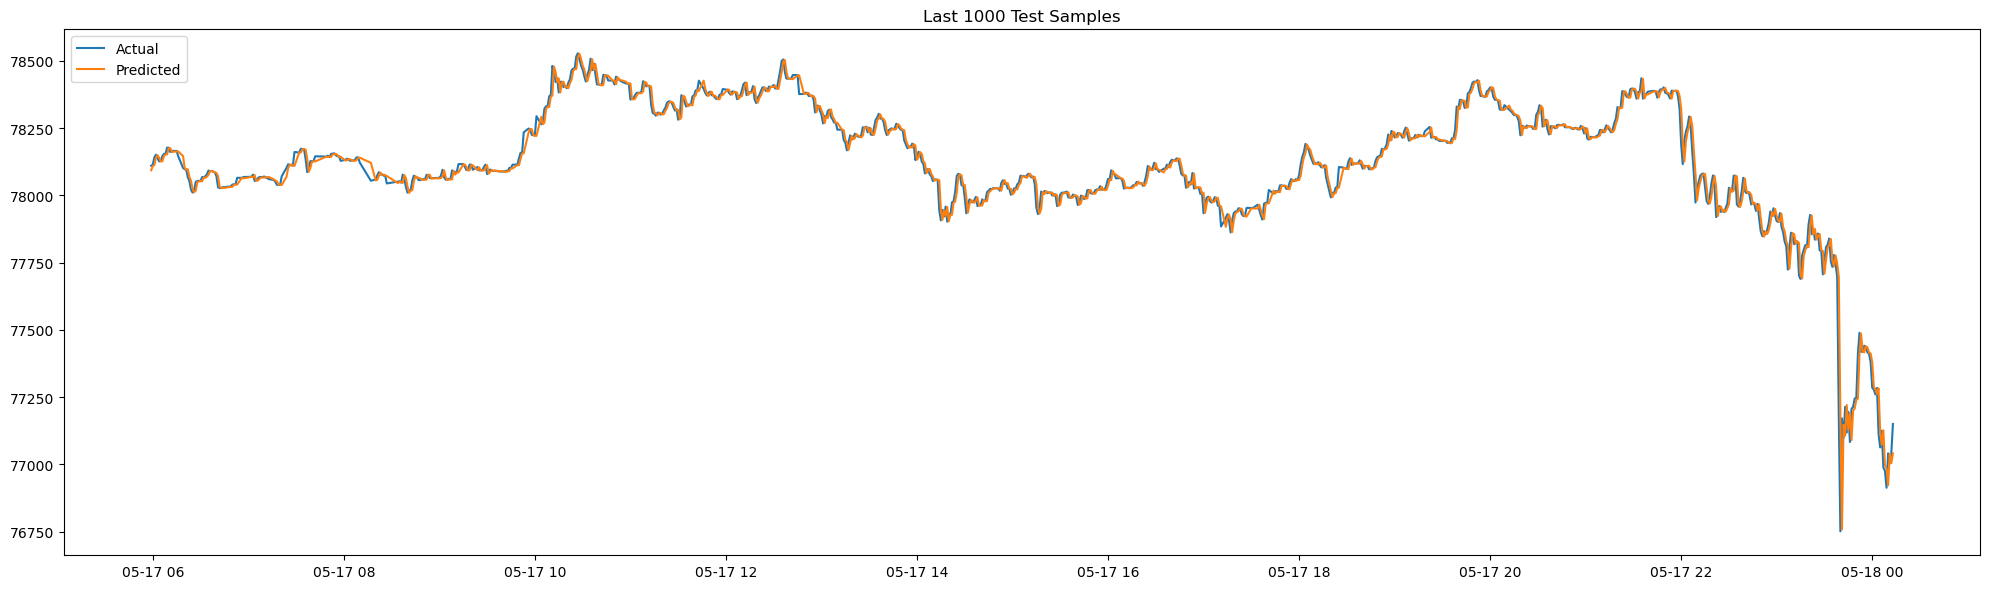

In [16]:
last_n = 1000
plt.figure(figsize=(20, 6))

plt.plot(
    test_plot_time.iloc[-last_n:],
    y_test_actual.iloc[-last_n:],
    label='Actual'
)

plt.plot(
    test_plot_time.iloc[-last_n:],
    test_preds_actual[-last_n:],
    label='Predicted'
)

plt.title(f'Last {last_n} Test Samples')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [15]:
direction_correct = (
    np.sign(test_return_preds) ==
    np.sign(y_test.values)
)

direction_accuracy = direction_correct.mean()

print(f"Direction Accuracy: {direction_accuracy:.2%}")

Direction Accuracy: 46.55%


In [17]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': forest_reg.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

print(importance_df)

            feature  importance
4          return_1    0.203484
8       dist_sma_30    0.132079
7       dist_sma_10    0.104852
5          return_5    0.099689
3          body_pct    0.095947
6         return_10    0.071299
10    volume_change    0.068241
9     volatility_10    0.061560
2   price_range_pct    0.043315
1          log_open    0.042603
0         log_close    0.033927
11             hour    0.021901
12        dayofweek    0.012567
13            month    0.008537
